# WTI MM — Lead/Lag Analysis with Synthetic Spread (250d hedge ratio)

Does the hedge-ratio-adjusted synthetic spread lead or lag MM positioning?

Synthetic spread = `F1 - beta_ols_250 * F2`, where `beta_ols_250` is a
rolling 250-day OLS hedge ratio.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import sys; sys.path.append('../../../../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Load COT + synthetic spread

In [2]:
COT_PATH = '/Users/oualid/Documents/Projects/omroot_repos/cftc_data/cftc_downloads/disaggregated_combined.csv'

raw = pd.read_csv(COT_PATH, low_memory=False)
WTI_CODES = ['067651', '067411']
wti_raw = raw[raw['cftc_contract_market_code'].isin(WTI_CODES)].copy()
wti_raw['as_of_date'] = pd.to_datetime(wti_raw['report_date_as_yyyy_mm_dd'])

_SUM_COLS = [
    'open_interest_all',
    'm_money_positions_long_all', 'm_money_positions_short_all',
]
for c in _SUM_COLS:
    wti_raw[c] = pd.to_numeric(wti_raw[c], errors='coerce')

wti = wti_raw.groupby('as_of_date')[_SUM_COLS].sum().reset_index()
days_ahead = (4 - wti['as_of_date'].dt.dayofweek) % 7
wti['release_date'] = wti['as_of_date'] + pd.to_timedelta(days_ahead, unit='D')
wti['open_interest'] = wti['open_interest_all']
wti['mm_net'] = (wti['m_money_positions_long_all']
               - wti['m_money_positions_short_all'])
wti['mm_net_oi'] = wti['mm_net'] / wti['open_interest'] * 100
wti.sort_values('as_of_date', inplace=True)
wti.reset_index(drop=True, inplace=True)

cot = wti[['as_of_date', 'release_date', 'mm_net', 'mm_net_oi', 'open_interest']].copy()
print(f'COT rows: {len(cot)}')

COT rows: 1033


In [3]:
spread_db = pd.read_csv('../../../../cache/preprocessed_data/wti_synthetic_spread_db.csv')
spread_db['tradeDate'] = pd.to_datetime(spread_db['tradeDate'])
spread_db['SyntheticSpread'] = (spread_db['F1_RolledPrice']
                               - spread_db['beta_ols_250'] * spread_db['F2_RolledPrice'])
spread_db = spread_db[['tradeDate', 'SyntheticSpread']].dropna()
spread_db.sort_values('tradeDate', inplace=True)

print(f'Spread rows: {len(spread_db)}')
print(f'Range: {spread_db["tradeDate"].min().date()} -> {spread_db["tradeDate"].max().date()}')

Spread rows: 3671
Range: 2010-12-30 -> 2025-08-05


## 2. Join on release date and compute weekly changes

In [4]:
df = pd.merge_asof(
    cot.sort_values('as_of_date'),
    spread_db.rename(columns={'tradeDate': 'as_of_date'}),
    on='as_of_date', direction='backward', tolerance=pd.Timedelta(days=3),
)
df.dropna(subset=['mm_net', 'SyntheticSpread'], inplace=True)
df.sort_values('as_of_date', inplace=True)
df.reset_index(drop=True, inplace=True)

df['mm_net_chg']    = df['mm_net'].diff()
df['mm_net_oi_chg'] = df['mm_net_oi'].diff()
df['synth_chg']     = df['SyntheticSpread'].diff()

df.dropna(subset=['mm_net_chg', 'synth_chg'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Clean rows: {len(df)}')
print(f'Range: {df["as_of_date"].min().date()} -> {df["as_of_date"].max().date()}')

Clean rows: 760
Range: 2011-01-11 -> 2025-08-05


## 3. Contemporaneous correlation

In [5]:
rho_raw, p_raw = sp_stats.spearmanr(df['mm_net_chg'], df['synth_chg'])
rho_oi, p_oi   = sp_stats.spearmanr(df['mm_net_oi_chg'], df['synth_chg'])

print('Contemporaneous (same week):')
print(f'  MM net change vs synth spread change:    rho = {rho_raw:+.3f}  (p = {p_raw:.1e})')
print(f'  MM net/OI change vs synth spread change: rho = {rho_oi:+.3f}  (p = {p_oi:.1e})')

Contemporaneous (same week):
  MM net change vs synth spread change:    rho = +0.083  (p = 2.2e-02)
  MM net/OI change vs synth spread change: rho = +0.089  (p = 1.4e-02)


## 4. Cross-correlation function

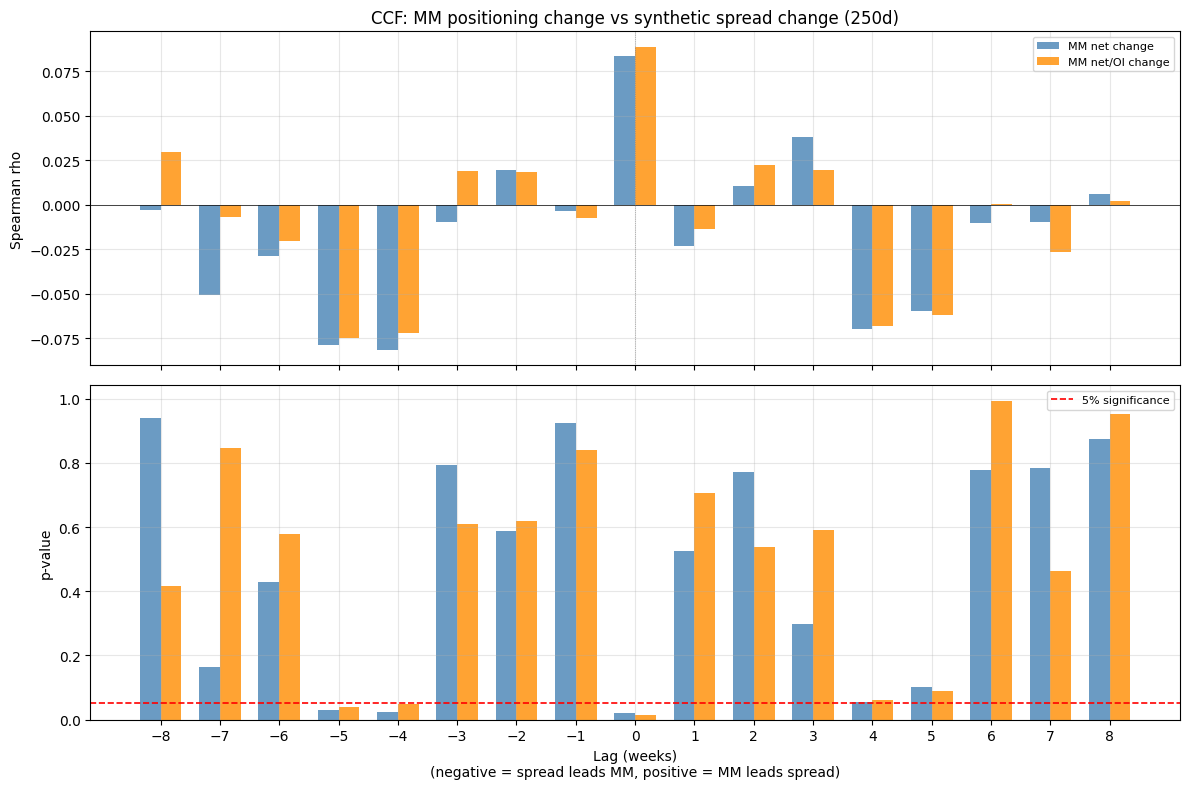

 Lag   rho (raw)       p-val    rho (OI)       p-val  Interpretation
-------------------------------------------------------------------------------------
  -8     -0.003       9.4e-01     +0.030       4.2e-01  spread leads MM by 8w
  -7     -0.051       1.6e-01     -0.007       8.5e-01  spread leads MM by 7w
  -6     -0.029       4.3e-01     -0.020       5.8e-01  spread leads MM by 6w
  -5     -0.079 *     3.0e-02     -0.075 *     4.0e-02  spread leads MM by 5w
  -4     -0.082 *     2.5e-02     -0.072 *     4.8e-02  spread leads MM by 4w
  -3     -0.010       7.9e-01     +0.019       6.1e-01  spread leads MM by 3w
  -2     +0.020       5.9e-01     +0.018       6.2e-01  spread leads MM by 2w
  -1     -0.003       9.2e-01     -0.007       8.4e-01  spread leads MM by 1w
   0     +0.083 *     2.2e-02     +0.089 *     1.4e-02  same week
   1     -0.023       5.3e-01     -0.014       7.1e-01  MM leads spread by 1w
   2     +0.011       7.7e-01     +0.022       5.4e-01  MM leads spread by 2w

In [6]:
MAX_LAG = 8

def compute_ccf(x, y, max_lag):
    lags = range(-max_lag, max_lag + 1)
    rhos, pvals = [], []
    for k in lags:
        if k >= 0:
            rho, p = sp_stats.spearmanr(x[:len(x)-k], y[k:])
        else:
            rho, p = sp_stats.spearmanr(x[-k:], y[:len(y)+k])
        rhos.append(rho)
        pvals.append(p)
    return list(lags), rhos, pvals

net_vals = df['mm_net_chg'].values
oi_vals  = df['mm_net_oi_chg'].values
synth_vals = df['synth_chg'].values

lags, rhos_raw, pvals_raw = compute_ccf(net_vals, synth_vals, MAX_LAG)
_, rhos_oi, pvals_oi = compute_ccf(oi_vals, synth_vals, MAX_LAG)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
bar_width = 0.35
x_pos = np.array(lags)

ax = axes[0]
ax.bar(x_pos - bar_width/2, rhos_raw, bar_width, color='steelblue',
       alpha=0.8, label='MM net change')
ax.bar(x_pos + bar_width/2, rhos_oi, bar_width, color='darkorange',
       alpha=0.8, label='MM net/OI change')
ax.axhline(0, color='black', lw=0.5)
ax.axvline(0, color='grey', lw=0.5, linestyle=':')
ax.set_ylabel('Spearman rho')
ax.set_title('CCF: WTI MM positioning change vs synthetic spread change (250d)')
ax.legend(fontsize=8)

ax = axes[1]
ax.bar(x_pos - bar_width/2, pvals_raw, bar_width, color='steelblue', alpha=0.8)
ax.bar(x_pos + bar_width/2, pvals_oi, bar_width, color='darkorange', alpha=0.8)
ax.axhline(0.05, color='red', linestyle='--', lw=1.2, label='5% significance')
ax.set_ylabel('p-value')
ax.set_xlabel('Lag (weeks)\n'
              '(negative = spread leads MM, positive = MM leads spread)')
ax.set_xticks(lags)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'{"Lag":>4s}  {"rho (raw)":>10s}  {"p-val":>10s}  {"rho (OI)":>10s}  {"p-val":>10s}  Interpretation')
print('-' * 85)
for k, rr, pr, ro, po in zip(lags, rhos_raw, pvals_raw, rhos_oi, pvals_oi):
    sig_r = '*' if pr < 0.05 else ' '
    sig_o = '*' if po < 0.05 else ' '
    if k < 0:
        interp = f'spread leads MM by {-k}w'
    elif k == 0:
        interp = 'same week'
    else:
        interp = f'MM leads spread by {k}w'
    print(f'{k:>4d}  {rr:>+9.3f} {sig_r}  {pr:>10.1e}  {ro:>+9.3f} {sig_o}  {po:>10.1e}  {interp}')

## 5a. 5-year blocks

In [7]:
df['year'] = df['as_of_date'].dt.year

blocks_5y = [
    ('2011-2015', (2011, 2015)),
    ('2016-2020', (2016, 2020)),
    ('2021-2025', (2021, 2025)),
]

KEY = [-2, -1, 0, 1, 2]
print(f'{"Block":>12s}  {"n":>4s}', end='')
for k in KEY:
    print(f'  lag {k:+d}', end='')
print()
print('-' * (22 + 9 * len(KEY)))

for label, (y_start, y_end) in blocks_5y + [('Full sample', (2011, 2025))]:
    sub = df[(df['year'] >= y_start) & (df['year'] <= y_end)]
    mm_b = sub['mm_net_chg'].values
    sy_b = sub['synth_chg'].values
    print(f'{label:>12s}  {len(sub):>4d}', end='')
    for k in KEY:
        if k >= 0:
            rho, _ = sp_stats.spearmanr(
                mm_b[:len(mm_b)-k] if k > 0 else mm_b,
                sy_b[k:] if k > 0 else sy_b)
        else:
            rho, _ = sp_stats.spearmanr(mm_b[-k:], sy_b[:len(sy_b)+k])
        print(f'  {rho:+.3f}', end='')
    print()


       Block     n  lag -2  lag -1  lag +0  lag +1  lag +2
-------------------------------------------------------------------
   2011-2015   259  +0.063  -0.015  +0.139  -0.071  -0.082
   2016-2020   261  -0.007  +0.044  +0.079  +0.003  +0.077
   2021-2025   240  +0.026  -0.020  +0.063  -0.007  +0.033
 Full sample   760  +0.020  -0.003  +0.083  -0.023  +0.011


## 5b. 3-year blocks

In [8]:
blocks_3y = [
    ('2011-2013', (2011, 2013)),
    ('2014-2016', (2014, 2016)),
    ('2017-2019', (2017, 2019)),
    ('2020-2022', (2020, 2022)),
    ('2023-2025', (2023, 2025)),
]

print(f'{"Block":>12s}  {"n":>4s}', end='')
for k in KEY:
    print(f'  lag {k:+d}', end='')
print()
print('-' * (22 + 9 * len(KEY)))

for label, (y_start, y_end) in blocks_3y + [('Full sample', (2011, 2025))]:
    sub = df[(df['year'] >= y_start) & (df['year'] <= y_end)]
    mm_b = sub['mm_net_chg'].values
    sy_b = sub['synth_chg'].values
    print(f'{label:>12s}  {len(sub):>4d}', end='')
    for k in KEY:
        if k >= 0:
            rho, _ = sp_stats.spearmanr(
                mm_b[:len(mm_b)-k] if k > 0 else mm_b,
                sy_b[k:] if k > 0 else sy_b)
        else:
            rho, _ = sp_stats.spearmanr(mm_b[-k:], sy_b[:len(sy_b)+k])
        print(f'  {rho:+.3f}', end='')
    print()


       Block     n  lag -2  lag -1  lag +0  lag +1  lag +2
-------------------------------------------------------------------
   2011-2013   155  +0.132  +0.084  +0.147  -0.075  -0.080
   2014-2016   156  -0.027  -0.072  +0.038  -0.109  -0.020
   2017-2019   157  -0.001  +0.064  +0.240  +0.002  +0.045
   2020-2022   156  +0.089  -0.029  +0.228  -0.025  +0.013
   2023-2025   136  -0.017  -0.030  -0.131  +0.015  +0.037
 Full sample   760  +0.020  -0.003  +0.083  -0.023  +0.011


## 5c. 2-year blocks

In [9]:

blocks_2y = [
    ('2011-2012', (2011, 2012)),
    ('2013-2014', (2013, 2014)),
    ('2015-2016', (2015, 2016)),
    ('2017-2018', (2017, 2018)),
    ('2019-2020', (2019, 2020)),
    ('2021-2022', (2021, 2022)),
    ('2023-2025', (2023, 2025)),
]

KEY = [-2, -1, 0, 1, 2]
print(f'{"Block":>12s}  {"n":>4s}', end='')
for k in KEY:
    print(f'  lag {k:+d}', end='')
print()
print('-' * (22 + 9 * len(KEY)))

for label, (y_start, y_end) in blocks_2y + [('Full sample', (2011, 2025))]:
    sub = df[(df['year'] >= y_start) & (df['year'] <= y_end)]
    mm_b = sub['mm_net_chg'].values
    sy_b = sub['synth_chg'].values
    print(f'{label:>12s}  {len(sub):>4d}', end='')
    for k in KEY:
        if k >= 0:
            rho, _ = sp_stats.spearmanr(
                mm_b[:len(mm_b)-k] if k > 0 else mm_b,
                sy_b[k:] if k > 0 else sy_b)
        else:
            rho, _ = sp_stats.spearmanr(mm_b[-k:], sy_b[:len(sy_b)+k])
        print(f'  {rho:+.3f}', end='')
    print()

       Block     n  lag -2  lag -1  lag +0  lag +1  lag +2
-------------------------------------------------------------------
   2011-2012   103  +0.226  +0.110  +0.309  -0.015  -0.025
   2013-2014   104  -0.100  -0.079  -0.030  -0.139  -0.226
   2015-2016   104  +0.059  -0.033  +0.038  -0.118  +0.165
   2017-2018   105  -0.019  +0.102  +0.311  -0.050  +0.028
   2019-2020   104  +0.023  -0.002  -0.011  +0.101  +0.070
   2021-2022   104  +0.090  -0.056  +0.398  -0.057  +0.019
   2023-2025   136  -0.017  -0.030  -0.131  +0.015  +0.037
 Full sample   760  +0.020  -0.003  +0.083  -0.023  +0.011


## 6. Rolling 52-week correlation

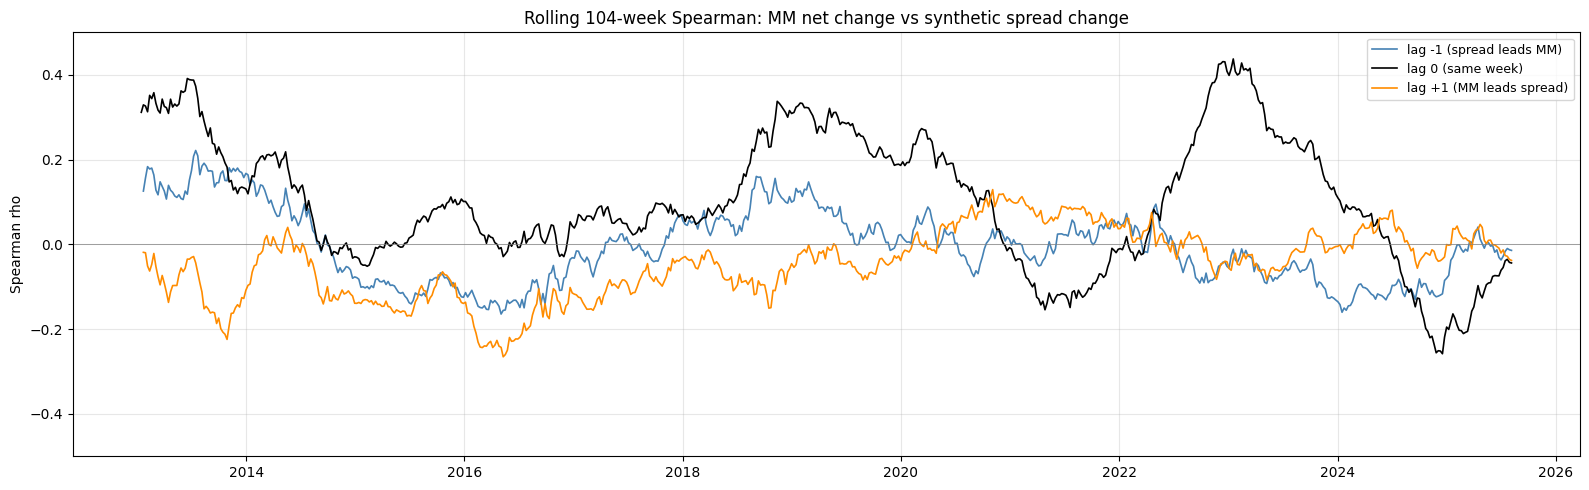

In [10]:
WINDOW = 104

fig, ax = plt.subplots(figsize=(16, 5))
for k, color, label in [(-1, 'steelblue', 'lag -1 (spread leads MM)'),
                          (0, 'black', 'lag 0 (same week)'),
                          (1, 'darkorange', 'lag +1 (MM leads spread)')]:
    rhos = []
    for i in range(len(net_vals)):
        if i < WINDOW + abs(k):
            rhos.append(np.nan)
            continue
        if k >= 0:
            rho, _ = sp_stats.spearmanr(
                net_vals[i-WINDOW:i-k] if k > 0 else net_vals[i-WINDOW:i],
                synth_vals[i-WINDOW+k:i] if k > 0 else synth_vals[i-WINDOW:i])
        else:
            rho, _ = sp_stats.spearmanr(
                net_vals[i-WINDOW-k:i],
                synth_vals[i-WINDOW:i+k])
        rhos.append(rho)
    ax.plot(df['as_of_date'], rhos, label=label, color=color, lw=1.2)

ax.axhline(0, color='grey', lw=0.5)
ax.set_title(f'Rolling {WINDOW}-week Spearman: WTI MM net change vs synthetic spread change')
ax.set_ylabel('Spearman rho')
ax.set_ylim(-0.5, 0.5)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()